## CSV 8: Messy Categorical Values (Human Errors & Inconsistency)

**Description**  
A simulated manual CRM entry dataset with inconsistent categorical values caused by evolving naming standards, human typos, casing differences, abbreviations, and semantic duplicates.

**Purpose / What It Tests**
- Detection of inconsistent and duplicated categorical values
- Categorical normalization and clustering logic
- Transparency of grouping and cleaning assumptions
- Correct aggregation after normalization
- UX and trustworthiness for non-technical users


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(123)

N_ROWS = 2400

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date():
    return start_date + timedelta(days=random.randint(0, (end_date - start_date).days))

# Messy categorical variants
regions = [
    "North America", "north america", "NA", "N. America", "North-America",
    "Europe", "EU", "europe",
    "Asia", "asia", "APAC"
]

categories = [
    "Software", "software", "Soft ware",
    "Hardware", "hardware", "Hard ware"
]

channels = [
    "Inbound", "inbound", "In-bound",
    "Outbound", "out bound", "OUTBOUND",
    "Partner", "partner"
]

products = [
    ("CRM Pro", "CRM Pro"),
    ("CRM-Pro", "CRM Pro"),
    ("Analytics Suite", "Analytics Suite"),
    ("AnalyticsSuite", "Analytics Suite"),
    ("POS Terminal", "POS Terminal"),
    ("POS-Terminal", "POS Terminal"),
]

rows = []

for i in range(N_ROWS):
    product_raw, product_clean = random.choice(products)
    units = random.randint(1, 15)
    price = random.randint(300, 2000)

    rows.append({
        "order_id": f"O-{900000+i}",
        "order_date": random_date(),
        "customer_id": f"C-{random.randint(1000, 7000)}",
        "product_name": product_raw,      # 🚨 messy
        "category": random.choice(categories),
        "region": random.choice(regions),
        "channel": random.choice(channels),
        "units": units,
        "revenue": units * price,
        "stage": "Won"
    })

df = pd.DataFrame(rows)

df.to_csv("sales_messy_categories.csv", index=False)
print("CSV generated: sales_messy_categories.csv")


CSV generated: sales_messy_categories.csv


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_messy_categories.csv")

# Unique counts before cleaning
print("Unique regions:", df["region"].nunique())
print("Unique categories:", df["category"].nunique())
print("Unique channels:", df["channel"].nunique())
print("Unique products:", df["product_name"].nunique())

assert df["region"].nunique() > 8, "❌ Region values not messy enough"
assert df["category"].nunique() > 4, "❌ Category values not messy enough"
assert df["channel"].nunique() > 6, "❌ Channel values not messy enough"

# Show sample problematic values
print("\nSample region values:", df["region"].unique()[:10])
print("Sample category values:", df["category"].unique())
print("Sample channel values:", df["channel"].unique())

print("✅ Messy categorical conditions validated.")


Unique regions: 10
Unique categories: 6
Unique channels: 8
Unique products: 6

Sample region values: [nan 'asia' 'North America' 'Europe' 'Asia' 'APAC' 'N. America' 'europe'
 'North-America' 'EU']
Sample category values: ['Software' 'Hardware' 'software' 'hardware' 'Soft ware' 'Hard ware']
Sample channel values: ['inbound' 'OUTBOUND' 'In-bound' 'out bound' 'Partner' 'Outbound'
 'partner' 'Inbound']
✅ Messy categorical conditions validated.


Gold Truth Analysis

Total Revenue: 22069626


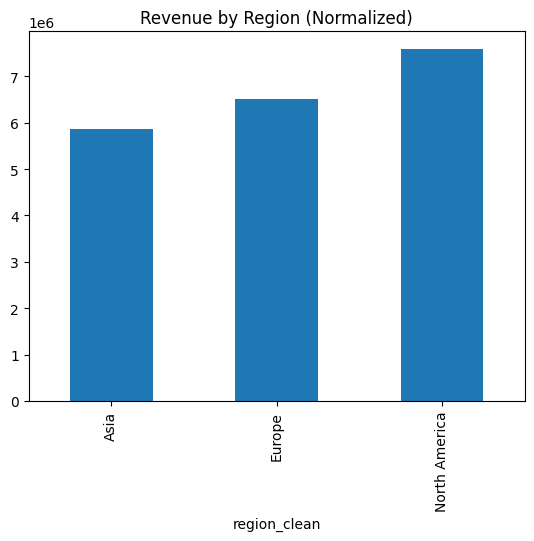

C:\Users\KRONOS\AppData\Local\Temp\ipykernel_48640\3767238249.py:92: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


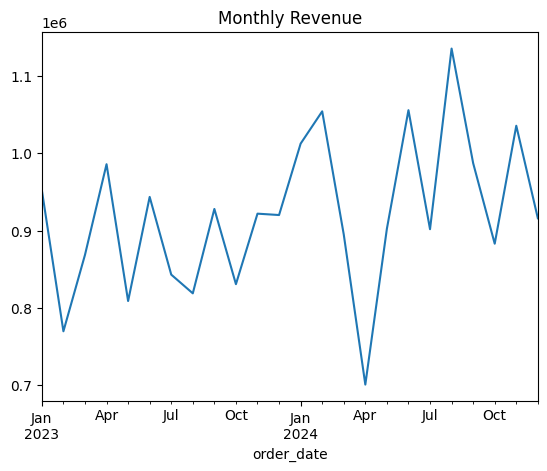

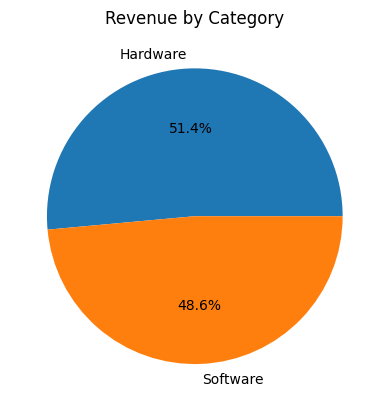

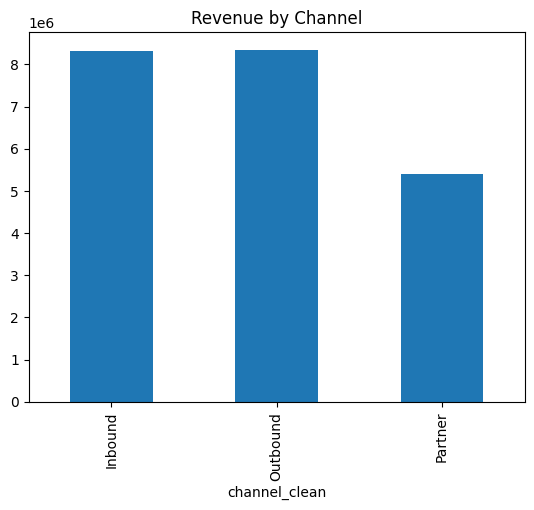

Raw region count: 10
Clean region count: 3
Raw category count: 6
Clean category count: 2


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_messy_categories.csv", parse_dates=["order_date"])

# ---------------------------
# Normalization mappings
# ---------------------------
region_map = {
    "north america": "North America",
    "na": "North America",
    "n. america": "North America",
    "north-america": "North America",
    "europe": "Europe",
    "eu": "Europe",
    "asia": "Asia",
    "apac": "Asia"
}

category_map = {
    "software": "Software",
    "soft ware": "Software",
    "hardware": "Hardware",
    "hard ware": "Hardware"
}

channel_map = {
    "inbound": "Inbound",
    "in-bound": "Inbound",
    "outbound": "Outbound",
    "out bound": "Outbound",
    "partner": "Partner"
}

product_map = {
    "crm-pro": "CRM Pro",
    "analyticsuite": "Analytics Suite",
    "pos-terminal": "POS Terminal"
}

# ---------------------------
# Apply normalization
# ---------------------------
df["region_clean"] = (
    df["region"]
    .str.strip()
    .str.lower()
    .replace(region_map)
)

df["category_clean"] = (
    df["category"]
    .str.strip()
    .str.lower()
    .replace(category_map)
)

df["channel_clean"] = (
    df["channel"]
    .str.strip()
    .str.lower()
    .replace(channel_map)
)

df["product_clean"] = (
    df["product_name"]
    .str.strip()
    .str.lower()
    .replace(product_map)
    .str.title()
)


# ---------------------------
# KPI 1: Total Revenue
# ---------------------------
total_revenue = df["revenue"].sum()
print("Total Revenue:", total_revenue)

# ---------------------------
# KPI 2: Revenue by Clean Region
# ---------------------------
region_revenue = df.groupby("region_clean")["revenue"].sum()
region_revenue.plot(kind="bar", title="Revenue by Region (Normalized)")
plt.show()

# ---------------------------
# Trend 1: Monthly Revenue
# ---------------------------
monthly_revenue = (
    df.set_index("order_date")
      .resample("M")["revenue"]
      .sum()
)

monthly_revenue.plot(title="Monthly Revenue")
plt.show()

# ---------------------------
# Trend 2: Revenue by Category (Clean)
# ---------------------------
category_revenue = df.groupby("category_clean")["revenue"].sum()
category_revenue.plot(kind="pie", autopct="%1.1f%%", title="Revenue by Category")
plt.ylabel("")
plt.show()

# ---------------------------
# Trend 3: Revenue by Channel (Clean)
# ---------------------------
channel_revenue = df.groupby("channel_clean")["revenue"].sum()
channel_revenue.plot(kind="bar", title="Revenue by Channel")
plt.show()

# ---------------------------
# KPI 3: Category Explosion Reduction
# ---------------------------
print("Raw region count:", df["region"].nunique())
print("Clean region count:", df["region_clean"].nunique())
print("Raw category count:", df["category"].nunique())
print("Clean category count:", df["category_clean"].nunique())
